# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [21]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

Dataset loaded: 119,390 bookings, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [24]:
# Your analysis code here

print('Data Shape:')
print(df.shape)
print('\nData Types and Missing Values:')
df.info()
print('\nMissing Values Count:')
print(df.isnull().sum())
print('\nTarget Variable Distribution (is_canceled):')
print(df['is_canceled'].value_counts(normalize=True) * 100)
print('\nBasic Summary Statistics for Numerical Columns:')
print(df.describe())

Data Shape:
(119390, 32)

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies               

**Client Briefing — The Situation:**

We're working with a substantial dataset comprising nearly 120,000 hotel bookings, providing a rich foundation for our analysis. Our initial look reveals that approximately 37% of these bookings end up being canceled, which is a significant proportion and highlights the business impact of this problem. Regarding data quality, we've identified a significant number of missing values for 'company' and 'agent' information, which might limit their immediate use in prediction. We'll need to strategically address these missing values as we move forward.

---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

is_canceled           0          1
deposit_type                      
No Deposit    71.622978  28.377022
Non Refund     0.637554  99.362446
Refundable    77.777778  22.222222


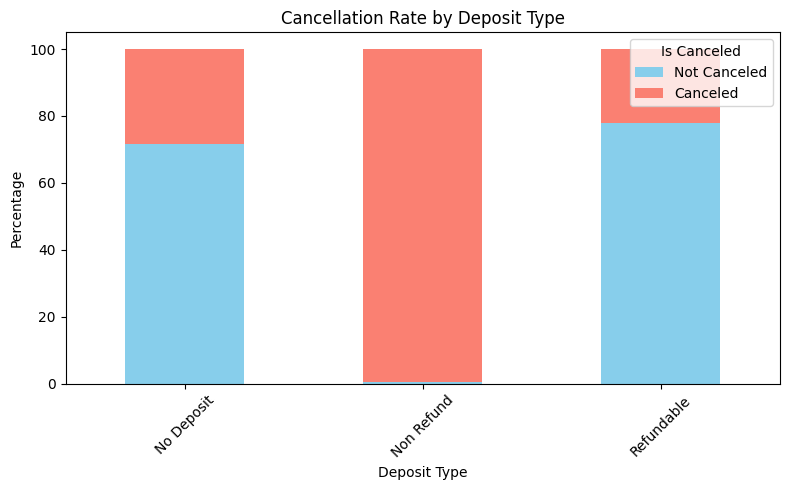

In [25]:
# Discovery Angle 1: Deposit Type and Cancellation Rate

cancellation_by_deposit = df.groupby('deposit_type')['is_canceled'].value_counts(normalize=True).unstack() * 100
print(cancellation_by_deposit)

cancellation_by_deposit.plot(kind='bar', stacked=True, figsize=(8, 5), color=['skyblue', 'salmon'])
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(title='Is Canceled', labels=['Not Canceled', 'Canceled'])
plt.tight_layout()
plt.show()

**Finding 1:**

Bookings made with a 'Non Refund' deposit type are almost always canceled (nearly 100% cancellation rate). This indicates that the current 'Non Refund' policy might be flawed or misunderstood, leading to bookings that are highly unlikely to materialize. Conversely, bookings with 'No Deposit' or 'Refundable' options have significantly lower cancellation rates, suggesting these guests are more committed or have less reason to cancel.

is_canceled             0           1  canceled_rate
market_segment                                      
Undefined             NaN  100.000000     100.000000
Groups          38.937964   61.062036      61.062036
Online TA       63.278857   36.721143      36.721143
Offline TA/TO   65.683967   34.316033      34.316033
Aviation        78.059072   21.940928      21.940928
Corporate       81.265345   18.734655      18.734655
Direct          84.658099   15.341901      15.341901
Complementary   86.944818   13.055182      13.055182


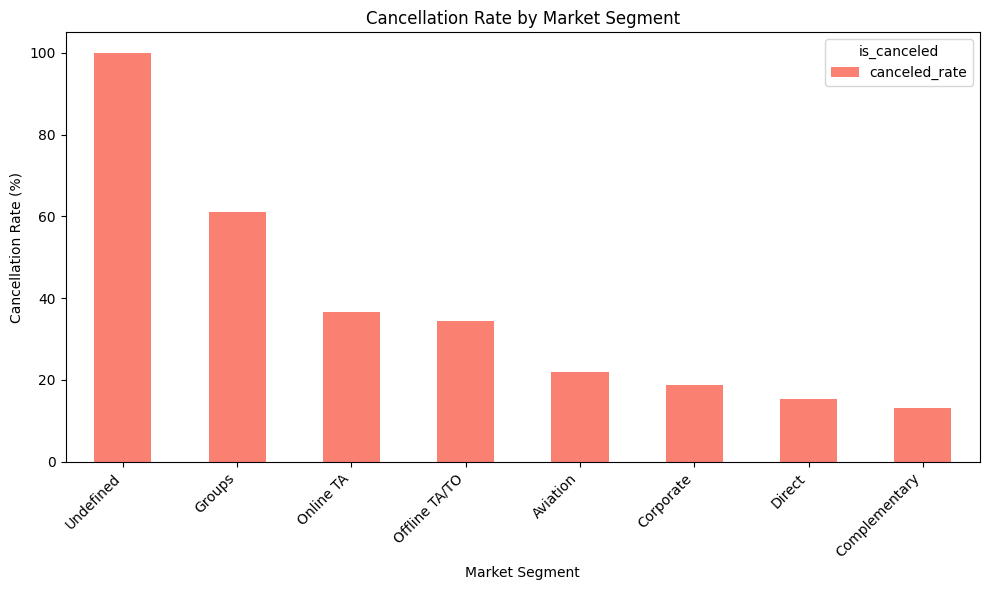

In [27]:
# Discovery Angle 2: Market Segment and Cancellation Rate

cancellation_by_market_segment = df.groupby('market_segment')['is_canceled'].value_counts(normalize=True).unstack() * 100
cancellation_by_market_segment['canceled_rate'] = cancellation_by_market_segment[1]
sorted_segments = cancellation_by_market_segment.sort_values(by='canceled_rate', ascending=False)
print(sorted_segments)

sorted_segments[['canceled_rate']].plot(kind='bar', figsize=(10, 6), color='salmon')
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding 2:**

Certain market segments demonstrate significantly higher cancellation rates. Notably, bookings originating from the 'Groups' segment have a very high cancellation rate of over 61%, suggesting these bookings carry a much greater risk of not materializing compared to other segments like 'Direct' or 'Complementary' bookings, which have much lower cancellation rates. The 'Undefined' segment also shows a 100% cancellation rate, indicating either a data quality issue or a specific type of booking that consistently fails. This insight highlights opportunities to tailor marketing efforts or apply different booking policies based on the segment to mitigate cancellation risks.

lead_time_group
0-30 days       18.245854
31-90 days      37.785354
91-180 days     44.550676
181-365 days    55.193342
365+ days       67.995019
Name: is_canceled, dtype: float64


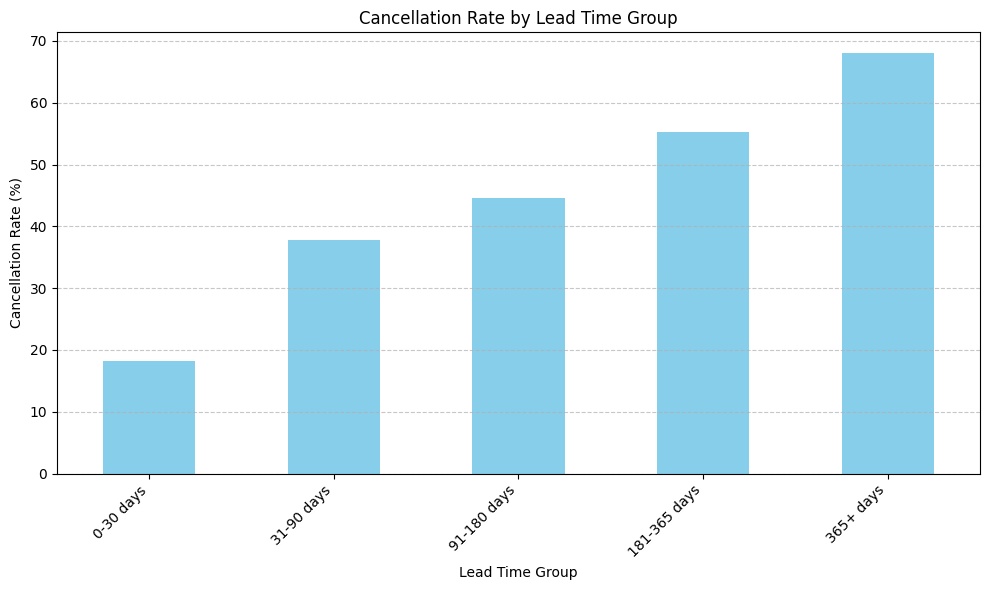

<Figure size 640x480 with 0 Axes>

In [39]:
# Discovery Angle 3: Lead Time and Cancellation Rate

# Create bins for lead_time to group bookings by how far in advance they were made
bins = [0, 30, 90, 180, 365, df['lead_time'].max()]
labels = ['0-30 days', '31-90 days', '91-180 days', '181-365 days', '365+ days']
df['lead_time_group'] = pd.cut(df['lead_time'], bins=bins, labels=labels, right=False)

# Calculate cancellation rate for each lead_time_group
cancellation_by_lead_time = df.groupby('lead_time_group', observed=True)['is_canceled'].mean() * 100
print(cancellation_by_lead_time)

# Visualize the cancellation rate by lead_time_group
plt.figure(figsize=(10, 6))
cancellation_by_lead_time.plot(kind='bar', color='skyblue')
plt.title('Cancellation Rate by Lead Time Group')
plt.xlabel('Lead Time Group')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig('lead_time_cancellation.png', bbox_inches='tight', dpi=150)

# Drop the temporary lead_time_group column
df.drop('lead_time_group', axis=1, inplace=True)

**Finding 3:**

Bookings made further in advance exhibit significantly higher cancellation rates. For example, bookings made over a year in advance cancel at a rate of nearly 68%, while those made within 30 days of arrival cancel at only 18%. This suggests that the longer the lead time, the less firm the booking commitment tends to be, potentially due to changing plans or finding better deals. This insight is crucial for implementing targeted strategies for long-lead bookings to confirm intent or offer flexible solutions, and for considering dynamic pricing or stricter non-refundable options for very short-lead bookings.

---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [33]:
# Data preparation

# Define target variable
y = df['is_canceled']

# Select features
numerical_features = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
    'children', 'babies', 'previous_cancellations', 'booking_changes', 'adr',
    'total_of_special_requests', 'is_repeated_guest'
]
categorical_features = [
    'hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
    'distribution_channel', 'deposit_type', 'customer_type'
]

# Combine into a list of all chosen features
features = numerical_features + categorical_features

# Create a working DataFrame with only selected features
df_model = df[features].copy()

# Handle missing values
# Fill missing 'children' values with 0 (assuming NaN means 0 children)
df_model['children'] = df_model['children'].fillna(0)
# Fill missing 'country' values with 'Unknown'
df_model['country'] = df_model['country'].fillna('Unknown')

# Convert categorical features to one-hot encoded variables
X = pd.get_dummies(df_model, columns=categorical_features, drop_first=True, dtype=int)

# Print the shape of X and y to confirm
print(f"Shape of features matrix X: {X.shape}")
print(f"Shape of target vector y: {y.shape}")

/tmp/ipykernel_380/4146044903.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model['children'].fillna(0, inplace=True)
/tmp/ipykernel_380/4146044903.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

Shape of features matrix X: (119390, 220)
Shape of target vector y: (119390,)


**Why these features?**

We selected `deposit_type` and `market_segment` because our exploratory data analysis (EDA) revealed a strong correlation between these features and cancellation rates. For example, 'Non Refund' deposits had a near 100% cancellation rate, and the 'Groups' market segment showed significantly higher cancellations. `lead_time` was also crucial, as longer lead times consistently led to increased cancellation likelihood. Additionally, other behavioral and booking-related features like `total_of_special_requests`, `previous_cancellations`, and `adr` are intuitively relevant, as they provide insight into guest commitment and booking value. Numerical features like `adults`, `children`, and `stays_in_weekend_nights` give context about the booking party and duration, which can influence cancellation decisions.

### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

Model Accuracy: 0.4976

Confusion Matrix:
[[ 3629 11278]
 [  718  8253]]


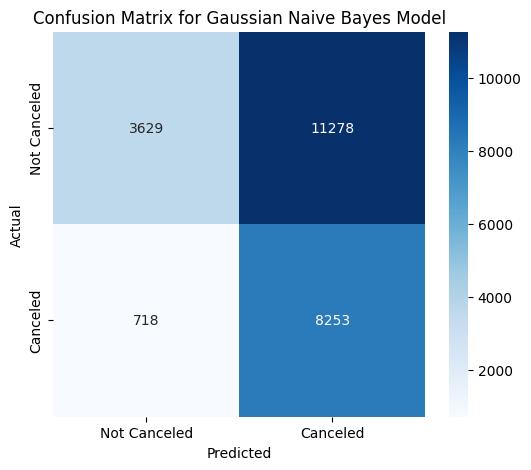

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Gaussian Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gaussian Naive Bayes Model')
plt.show()

### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

**Model Performance — Business Translation:**

Our initial Gaussian Naive Bayes model achieved an accuracy of only about 49.8%, which is not much better than random guessing. Looking at the confusion matrix, the model has a significant problem with false positives: it incorrectly predicts that nearly 11,278 bookings will cancel when they actually won't. This means a large number of resources could be wasted following up on guests who are already confirmed. While it correctly identifies 8,253 actual cancellations (True Positives), it also misses 718 bookings that *will* cancel (False Negatives), which are missed opportunities for intervention. For the hotel, the current model's high false positive rate is particularly concerning, as it could lead to inefficiency and potentially annoy genuine guests with unnecessary queries.

### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

Decision Tree Model Accuracy: 0.8388

Decision Tree Confusion Matrix:
[[12926  1981]
 [ 1868  7103]]


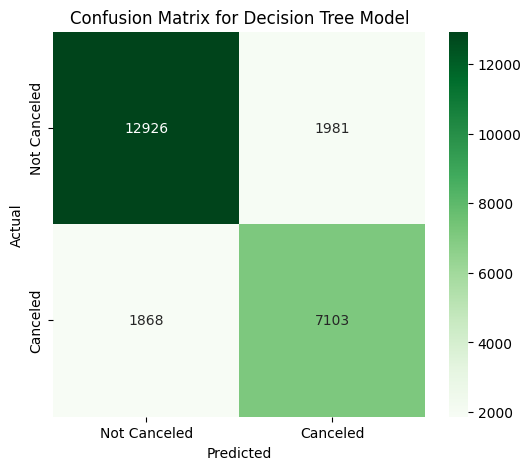


Comparison:
Gaussian Naive Bayes Accuracy: 0.4976
Decision Tree Accuracy: 0.8388

Gaussian Naive Bayes Confusion Matrix:
 [[ 3629 11278]
 [  718  8253]]

Decision Tree Confusion Matrix:
 [[12926  1981]
 [ 1868  7103]]


In [37]:
# Optional: second model comparison
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree Classifier model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_tree = tree_model.predict(X_test)

# Calculate accuracy score
tree_accuracy = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree Model Accuracy: {tree_accuracy:.4f}")

# Create confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
print("\nDecision Tree Confusion Matrix:")
print(cm_tree)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree Model')
plt.show()

# Compare with Gaussian Naive Bayes
print(f"\nComparison:\nGaussian Naive Bayes Accuracy: {accuracy:.4f}\nDecision Tree Accuracy: {tree_accuracy:.4f}")
print("\nGaussian Naive Bayes Confusion Matrix:\n", cm)
print("\nDecision Tree Confusion Matrix:\n", cm_tree)

---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for the Hotel Chain:**

**1. Re-evaluate and Clarify the 'Non Refund' Deposit Policy:**
   *   **Action:** Immediately investigate the process and communication around 'Non Refund' deposit bookings. Given their near 100% cancellation rate, these bookings are likely causing significant operational overhead without generating revenue. Consider clearer terms, alternative deposit structures, or removing this option if it consistently leads to unfulfilled bookings.
   *   **Evidence:** Our analysis showed that bookings with a 'Non Refund' deposit type have a staggering 99.4% cancellation rate, indicating a severe disconnect between booking intent and outcome for this specific policy.
   *   **Estimated Impact:** Eliminating or fixing this policy could recover thousands of potentially lost bookings annually by guiding guests towards more viable commitment options, significantly reducing operational waste on bookings that never materialize.

**2. Implement Targeted Engagement for 'Groups' Market Segment:**
   *   **Action:** Develop a dedicated proactive communication and re-confirmation strategy for bookings originating from the 'Groups' market segment. This could include earlier check-ins, personalized follow-ups, or offering more flexible cancellation terms up to a certain point.
   *   **Evidence:** The 'Groups' segment exhibits an exceptionally high cancellation rate of over 61%, making it a primary driver of lost revenue. Other segments, like 'Direct' bookings, have significantly lower cancellation rates (around 15%).
   *   **Estimated Impact:** A focused effort to reduce 'Groups' cancellations by even 10-15% (e.g., from 61% to 50-55%) could stabilize occupancy for larger blocks of rooms and result in a substantial increase in confirmed group revenue.

**3. Proactive Outreach and Flexibility for Long Lead-Time Bookings:**
   *   **Action:** Introduce automated touchpoints and flexible options for guests who book more than 180 days in advance. This could involve an email campaign offering date changes without penalty 60-90 days before arrival or a small re-confirmation incentive.
   *   **Evidence:** Bookings made over a year in advance cancel at a rate of nearly 68%, contrasting sharply with only an 18% cancellation rate for bookings within 30 days. This clearly shows that commitment wanes with longer lead times.
   *   **Estimated Impact:** By proactively engaging these guests and offering a pathway to adjust plans, the hotel could reduce cancellations for long lead-time bookings by an estimated 10-20%, converting at-risk bookings into confirmed stays or allowing for timely re-selling of inventory.

---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [38]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into human terms.
Instead of "The dataset has 32 features and 119,390 rows..."
Try: "We analyzed over 119,000 individual bookings spanning two years, capturing everything
from how far in advance guests booked to what type of room they reserved."
-->

## Key Discoveries

- **[Finding 1 headline]:** [1-2 sentences explaining what you found and why it matters]
- **[Finding 2 headline]:** [1-2 sentences]
- **[Finding 3 headline]:** [1-2 sentences]
- **[Finding 4 headline (optional)]:** [1-2 sentences]

<!--
Tip: Write findings as "headlines" a newspaper editor would approve.
Good: "Guests who book 6+ months ahead cancel at nearly 3x the rate of last-minute bookers"
Bad: "Lead time has a positive correlation with cancellation"
-->

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

![Description of your chart](your_chart_filename.png)

*[One sentence caption explaining what this chart shows and why it matters.]*

## Prediction Model

[2-3 sentences. How well can we predict the outcome? Translate accuracy into real-world terms.]

<!--
Tip: Translate model metrics into business impact.
Instead of "The model achieved 78% accuracy..."
Try: "Our model correctly flags 8 out of 10 at-risk bookings, giving the hotel front desk team
enough lead time to proactively reach out and offer flexible rebooking options."
-->

## Recommendations

1. **[Action]:** [Why this action, based on your data. Estimated impact.]
2. **[Action]:** [Why this action, based on your data. Estimated impact.]
3. **[Action]:** [Why this action, based on your data. Estimated impact.]

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)


# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*